# MPS and DMRG for a Finite Heisenberg Chain

**A pedagogical implementation of matrix product states and the density-matrix renormalization group, benchmarked against exact diagonalization for small open chains.**

---

## Abstract

The exact diagonalization (ED) of quantum spin chains is limited by the exponential growth of the Hilbert space. In this notebook we implement a small, transparent DMRG algorithm for the open spin-1/2 Heisenberg chain and compare it directly with ED for \(N=10\).

We start from the exact ground-state wavefunction and decompose it into a matrix product state (MPS) using sequential singular-value decompositions. This illustrates the meaning of bond dimension and entanglement. We then perform a canonical two-site DMRG sweep and show that the algorithm converges to the ED ground-state energy.

The final results include:

- ground-state energy
- local magnetization
- spin-spin correlations
- convergence with bond dimension
- entanglement entropy from Schmidt coefficients

This project emphasizes understanding and validation at small system sizes, rather than pushing DMRG to its computational limits.

## 1. Exact Diagonalization Benchmark

We work with the open-boundary Heisenberg chain

$$
H = J \sum_{i=1}^{N-1} \mathbf{S}_i \cdot \mathbf{S}_{i+1},
\qquad
\mathbf{S}_i = \frac{1}{2}\boldsymbol{\sigma}_i,
\qquad
J = 1.
$$

For $N=10$, the Hilbert-space dimension is

$$
2^{10} = 1024.
$$

Full ED is therefore straightforward. We construct $H$ using Kronecker products and find the ground-state energy and wavefunction.

These ED results will be our reference values for every later MPS/DMRG calculation.

In [15]:
import numpy as np
from scipy.linalg import eigh

# Single-spin operators
I2 = np.eye(2, dtype=complex)
Sx = 0.5 * np.array([[0, 1], [1, 0]], dtype=complex)
Sy = 0.5 * np.array([[0, -1j], [1j, 0]], dtype=complex)
Sz = 0.5 * np.array([[1, 0], [0, -1]], dtype=complex)
spin_ops = [Sx, Sy, Sz]

def kron_all(op_list):
    """Kronecker product of a list of operators."""
    result = op_list[0]
    for op in op_list[1:]:
        result = np.kron(result, op)
    return result

def build_heisenberg_obc(N, J=1.0):
    """
    Heisenberg Hamiltonian with open boundary conditions.

    H = J sum_{i=1}^{N-1} S_i · S_{i+1}
    """
    dim = 2**N
    H = np.zeros((dim, dim), dtype=complex)

    for site in range(N - 1):
        for spin_op in spin_ops:
            ops = [I2] * N
            ops[site] = spin_op
            ops[site + 1] = spin_op
            H += J * kron_all(ops)

    return H

# System size
N = 10

# Build Hamiltonian
H_ed = build_heisenberg_obc(N, J=1.0)

# Ground state
eigenvalues, eigenvectors = eigh(H_ed)

E0_ED = eigenvalues[0].real
psi_ED = eigenvectors[:, 0]

print(f"N = {N}")
print(f"Hilbert-space dimension = {2**N}")
print(f"ED ground-state energy = {E0_ED:.12f}")

N = 10
Hilbert-space dimension = 1024
ED ground-state energy = -4.258035207283


## 2. MPS Representation of the Exact Ground State

### From a full wavefunction to an MPS using SVD

We start from the exact ED ground-state vector

$$
|\psi\rangle
=
\sum_{s_1,\ldots,s_N}
c_{s_1\cdots s_N}
|s_1\cdots s_N\rangle.
$$

We want to represent the same state as an MPS:

$$
|\psi\rangle
=
\sum_{s_1,\ldots,s_N}
A_1^{s_1} A_2^{s_2} \cdots A_N^{s_N}
|s_1\cdots s_N\rangle.
$$

The bridge between these two descriptions is the singular value decomposition (SVD).

### Why SVD?

The SVD of a matrix $M$ is

$$
M = U S V^\dagger,
$$

where:

- $U$ has orthonormal columns,
- $S$ is diagonal with non-negative entries $s_\alpha$,
- $V$ has orthonormal rows.

The $s_\alpha$ are called singular values. They measure how much each bond index contributes to the correlations between the left and right parts of the system.

### Two spins

For $N=2$, the coefficients can be written as a $2\times 2$ matrix:

$$
M_{s_1,s_2} = c_{s_1 s_2}.
$$

Its SVD gives

$$
M_{s_1,s_2}
=
\sum_{\alpha}
U_{s_1,\alpha} \, s_\alpha \, (V^\dagger)_{\alpha,s_2}.
$$

Comparing with

$$
c_{s_1,s_2}
=
\sum_{\alpha}
A_1^{s_1} A_2^{s_2},
$$

we identify

$$
A_1^{s_1} \cong U,
\qquad
A_2^{s_2} \cong S V^\dagger.
$$

Thus the SVD automatically provides the MPS tensors for two sites.

### Three spins

For $N=3$:

1. Group site 1 on the left and sites 2,3 on the right:

   $$
   M_{s_1,(s_2 s_3)} = c_{s_1 s_2 s_3}.
   $$

2. SVD:

   $$
   M = U S V^\dagger.
   $$

   The factor $U$ becomes the first MPS tensor $A_1$.

3. The remainder $S V^\dagger$ still contains sites 2 and 3. Reshape it as a matrix with rows $(\alpha,s_2)$ and columns $s_3$:

   $$
   M'_{(\alpha s_2), s_3}.
   $$

4. SVD again:

   $$
   M' = U' S' V'^\dagger.
   $$

   Now $U'$ becomes site 2's tensor, and $S' V'^\dagger$ becomes site 3's tensor.

### General procedure

For a general chain, we repeat the same steps from left to right:

1. Reshape the current coefficient tensor into a matrix.
2. SVD the matrix.
3. Store the left orthonormal factor $U$ as the current site tensor.
4. Absorb the remaining factor $S V^\dagger$ and move to the next site.
5. At the last site, store the remaining tensor directly.

This gives a **full-rank MPS** representation of the exact state. Truncating the singular values at each step produces an MPS with controlled bond dimension.

The singular values also provide the entanglement entropy across each cut:

$$
S_{\rm vN}
=
-\sum_\alpha s_\alpha^2 \log s_\alpha^2.
$$

This is the central quantity that tells us how much bond dimension is needed and why MPS works so well for one-dimensional systems.

In [16]:
import numpy as np

def exact_wavefunction_to_mps(psi, N):
    """
    Convert an exact wavefunction vector into a full-rank MPS.

    Parameters
    ----------
    psi : ndarray of shape (2**N,)
        Exact ground-state wavefunction from ED.
    N : int
        Number of sites.

    Returns
    -------
    tensors : list of ndarray
        MPS tensors with bond dimensions equal to the true Schmidt ranks.
    """
    # Normalize the input state
    psi = psi / np.linalg.norm(psi)

    # Reshape the coefficient vector into a tensor with N physical legs
    coeff_tensor = psi.reshape([2] * N)

    tensors = []
    left_dim = 1

    # Process sites from left to right, except the last one
    for site in range(N - 1):
        # Reshape the current tensor into a matrix:
        # rows = left_dim * physical_dim_of_current_site
        # columns = all remaining physical degrees of freedom
        M = coeff_tensor.reshape(left_dim * 2, 2**(N - site - 1))

        # Singular value decomposition
        U, S, Vh = np.linalg.svd(M, full_matrices=False)

        # The new bond dimension is the number of nonzero singular values
        chi = len(S)

        # Store the left orthonormal factor as the current site tensor
        tensors.append(U.reshape(left_dim, 2, chi))

        # Absorb the remaining factor S Vh and move to the next site
        coeff_tensor = (np.diag(S) @ Vh).reshape([chi] + [2]*(N - site - 1))

        left_dim = chi

    # The final remaining tensor is the last site
    tensors.append(coeff_tensor.reshape(left_dim, 2, 1))

    return tensors

# Use the ED wavefunction from Part 1
mps_exact_tensors = exact_wavefunction_to_mps(psi_ED, N)

print("Full-rank MPS tensor shapes:")
for i, t in enumerate(mps_exact_tensors):
    print(f"Site {i}: shape = {t.shape}")

# Verify normalization: contract the MPS with itself
def mps_norm_squared(tensors):
    L = np.array([[1.0]], dtype=complex)
    for t in tensors:
        chiL, d, chiR = t.shape
        Lnew = np.zeros((chiR, chiR), dtype=complex)
        for s in range(d):
            As = t[:, s, :]
            Lnew += As.conj().T @ L @ As
        L = Lnew
    return np.real(L[0, 0])

norm2 = mps_norm_squared(mps_exact_tensors)
print(f"\nNorm squared of MPS = {norm2:.12f}")

Full-rank MPS tensor shapes:
Site 0: shape = (1, 2, 2)
Site 1: shape = (2, 2, 4)
Site 2: shape = (4, 2, 8)
Site 3: shape = (8, 2, 16)
Site 4: shape = (16, 2, 32)
Site 5: shape = (32, 2, 16)
Site 6: shape = (16, 2, 8)
Site 7: shape = (8, 2, 4)
Site 8: shape = (4, 2, 2)
Site 9: shape = (2, 2, 1)

Norm squared of MPS = 1.000000000000


## 3. Truncation and Bond Dimension Study

In the previous section we built a full-rank MPS from the exact ground state. That MPS has bond dimensions equal to the true Schmidt ranks, which for a finite chain may be as large as $2^{N/2}$. No compression has yet occurred.

The central approximation of MPS/DMRG is to keep only the largest singular values at each cut. If we truncate to a maximum bond dimension $\chi$, the state becomes an approximation:

$$
|\psi_\chi\rangle
\approx
\sum_{s_1,\ldots,s_N}
\tilde A_1^{s_1}\cdots\tilde A_N^{s_N}
|s_1\cdots s_N\rangle.
$$

The discarded weight at a cut is

$$
\epsilon_{\rm disc}
=
\sum_{\alpha > \chi}
s_\alpha^2.
$$

For states obeying the area law or having only logarithmic entanglement, a moderate $\chi$ already gives excellent accuracy.

In this section we start from the exact wavefunction, perform the same left-to-right SVD, but keep only the largest $\chi$ singular values at each bond. We then compute the energy of the truncated MPS and compare it with the exact ED result.

Since $N=10$ is small, this is a controlled test: we can see exactly how the accuracy improves as $\chi$ increases.

 chi       E_MPS                 E_MPS - E_ED
--------------------------------------------------
   2   -3.898205838349      3.598e-01
   4   -4.251109733108      6.925e-03
   6   -4.254332089666      3.703e-03
   8   -4.258019986546      1.522e-05
  12   -4.258032291800      2.915e-06
  16   -4.258035204597      2.686e-09
  32   -4.258035207283      2.665e-15


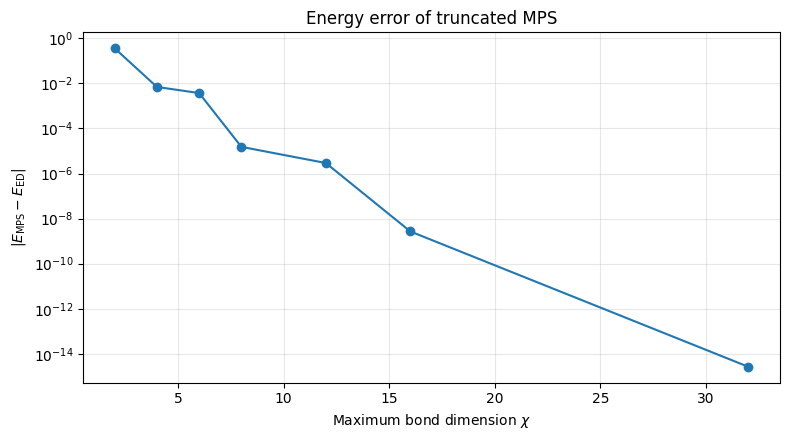

In [17]:
def truncated_wavefunction_to_mps(psi, N, chi_max):
    """
    Convert an exact wavefunction into an MPS with bond dimension ≤ chi_max.

    The truncation is done by keeping the largest chi_max singular values
    at each SVD step.
    """
    psi = psi / np.linalg.norm(psi)
    coeff_tensor = psi.reshape([2] * N)

    tensors = []
    left_dim = 1

    for site in range(N - 1):
        M = coeff_tensor.reshape(left_dim * 2, 2**(N - site - 1))
        U, S, Vh = np.linalg.svd(M, full_matrices=False)

        # Keep only the largest chi_max singular values
        chi = min(chi_max, len(S))
        U_trunc = U[:, :chi]
        S_trunc = S[:chi]
        Vh_trunc = Vh[:chi, :]

        # Store current site tensor
        tensors.append(U_trunc.reshape(left_dim, 2, chi))

        # Absorb S Vh and continue
        coeff_tensor = (np.diag(S_trunc) @ Vh_trunc).reshape([chi] + [2]*(N - site - 1))
        left_dim = chi

    # Last site
    tensors.append(coeff_tensor.reshape(left_dim, 2, 1))

    return tensors


def mps_energy_from_tensors(tensors, J=1.0):
    """
    Compute the energy of an MPS for the open Heisenberg chain.
    """
    N = len(tensors)
    d = 2

    # Left environments
    L = [np.array([[1.0]], dtype=complex)]
    for t in tensors:
        chiL, d, chiR = t.shape
        Lnew = np.zeros((chiR, chiR), dtype=complex)
        for s in range(d):
            As = t[:, s, :]
            Lnew += As.conj().T @ L[-1] @ As
        L.append(Lnew)

    # Right environments
    R = [None] * (N + 1)
    R[N] = np.array([[1.0]], dtype=complex)
    for i in range(N - 1, -1, -1):
        t = tensors[i]
        chiL, d, chiR = t.shape
        Rnew = np.zeros((chiL, chiL), dtype=complex)
        for s in range(d):
            As = t[:, s, :]
            Rnew += As @ R[i+1] @ As.conj().T
        R[i] = Rnew

    # Norm squared
    norm_sq = np.real(L[-1][0,0])

    # Energy
    E = 0.0
    for i in range(N - 1):
        A = tensors[i]
        B = tensors[i+1]
        chiL, _, chiM = A.shape
        _, _, chiR = B.shape

        for s1 in range(d):
            for s2 in range(d):
                for t1 in range(d):
                    for t2 in range(d):
                        # bond operator: J (Sx Sx + Sy Sy + Sz Sz)
                        if s1 == t1 and s2 == t2:
                            # diagonal part
                            diag = (s1 - 0.5) * (s2 - 0.5) * J
                        else:
                            diag = 0.0
                        # For off-diagonal, the bond operator has entries only for
                        # (0,1) <-> (1,0) with amplitude J/2.
                        if (s1 == 0 and s2 == 1 and t1 == 1 and t2 == 0) or \
                           (s1 == 1 and s2 == 0 and t1 == 0 and t2 == 1):
                            off_diag = J / 2
                        else:
                            off_diag = 0.0

                        op_val = diag + off_diag

                        if abs(op_val) > 1e-14:
                            # contraction
                            core = (
                                L[i] @ A[:, s1, :] @ B[:, s2, :] @
                                R[i+2] @ B[:, t2, :].conj().T @ A[:, t1, :].conj().T
                            )
                            E += np.real(op_val * np.trace(core))

    return E / norm_sq


# Values of chi to test
chi_values = [2, 4, 6, 8, 12, 16, 32]

energy_errors = []

print(" chi       E_MPS                 E_MPS - E_ED")
print("-" * 50)

for chi in chi_values:
    mps_tensors = truncated_wavefunction_to_mps(psi_ED, N, chi_max=chi)
    E_mps = mps_energy_from_tensors(mps_tensors, J=1.0)
    err = E_mps - E0_ED
    energy_errors.append(err)

    print(f"{chi:4d}   {E_mps:.12f}      {err:.3e}")

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4.5))
plt.semilogy(chi_values, np.maximum(np.abs(energy_errors), 1e-16), 'o-')
plt.xlabel(r"Maximum bond dimension $\chi$")
plt.ylabel(r"$|E_{\rm MPS} - E_{\rm ED}|$")
plt.title("Energy error of truncated MPS")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Two-Site DMRG Sweep

### From exact decomposition to variational optimization

In Parts 2 and 3 we started from an exact wavefunction and compressed it. DMRG takes the opposite approach: we start from a random MPS and variationally minimize the energy

$$
E =
\frac{\langle \psi | H | \psi \rangle}{\langle \psi | \psi \rangle}.
$$

We optimize only two neighboring MPS tensors at a time, keeping all other tensors fixed.

### Canonical form

An MPS has a gauge degree of freedom. We can bring it into **mixed canonical form** around a given bond. Then the left and right environments become identity matrices, and the local eigenvalue problem simplifies.

During a sweep, canonical form is maintained by SVD and by absorbing the singular values into the appropriate side depending on the sweep direction.

### Two-site update

At bond $(i,i+1)$:

1. Contract the two site tensors into a combined tensor $\Theta$.
2. Build the effective Hamiltonian $H_{\text{eff}}$ using the left and right environments and the MPO.
3. Solve the local eigenvalue problem

   $$
   H_{\text{eff}} \Theta = E \Theta.
   $$

4. Reshape $\Theta$ and perform SVD:

   $$
   \Theta = U S V^\dagger.
   $$

5. Truncate to $\chi_{\max}$ and split back into two site tensors.

### Sweeping

We sweep left-to-right and right-to-left many times. Each sweep lowers the energy until convergence to the ground state.

The code below uses a matrix-product-operator representation of the Hamiltonian, so the effective Hamiltonian is applied without ever constructing a large dense matrix.

In [18]:
import numpy as np
from scipy.sparse.linalg import LinearOperator, eigsh

# Spin operators
I2 = np.eye(2, dtype=complex)
Sx = 0.5 * np.array([[0, 1], [1, 0]], dtype=complex)
Sy = 0.5 * np.array([[0, -1j], [1j, 0]], dtype=complex)
Sz = 0.5 * np.array([[1, 0], [0, -1]], dtype=complex)
spin_ops = (Sx, Sy, Sz)

def heisenberg_mpo(N, J=1.0, h=0.0):
    """Open-boundary MPO for H = J sum S_i.S_{i+1} - h sum S_i^z."""
    W = []
    for i in range(N):
        if i == 0:
            Wi = np.zeros((1, 5, 2, 2), dtype=complex)
            Wi[0, 0] = I2
            Wi[0, 1] = J * Sx
            Wi[0, 2] = J * Sy
            Wi[0, 3] = J * Sz
            Wi[0, 4] = -h * Sz

        elif i == N - 1:
            Wi = np.zeros((5, 1, 2, 2), dtype=complex)
            Wi[0, 0] = -h * Sz
            Wi[1, 0] = Sx
            Wi[2, 0] = Sy
            Wi[3, 0] = Sz
            Wi[4, 0] = I2

        else:
            Wi = np.zeros((5, 5, 2, 2), dtype=complex)
            Wi[0, 0] = I2
            Wi[0, 1] = J * Sx
            Wi[0, 2] = J * Sy
            Wi[0, 3] = J * Sz
            Wi[0, 4] = -h * Sz
            Wi[1, 4] = Sx
            Wi[2, 4] = Sy
            Wi[3, 4] = Sz
            Wi[4, 4] = I2
        W.append(Wi)
    return W

def initial_neel_mps(N):
    """Product-state MPS |up down up down ...>."""
    A = []
    for i in range(N):
        v = np.array([1.0, 0.0], dtype=complex) if i % 2 == 0 else np.array([0.0, 1.0], dtype=complex)
        A.append(v.reshape(1, 2, 1))
    return A

def left_envs(A, W):
    """Left environments using the MPO."""
    L = [np.ones((1, 1, 1), dtype=complex)]
    for Ai, Wi in zip(A, W):
        Ln = np.einsum(
            'asr,axb,xyst,btq->ryq',
            Ai.conj(), L[-1], Wi, Ai,
            optimize=True
        )
        L.append(Ln)
    return L

def right_envs(A, W):
    """Right environments using the MPO."""
    N = len(A)
    R = [None] * (N + 1)
    R[N] = np.ones((1, 1, 1), dtype=complex)
    for i in range(N - 1, -1, -1):
        R[i] = np.einsum(
            'asr,xyst,btq,ryq->axb',
            A[i].conj(), W[i], A[i], R[i + 1],
            optimize=True
        )
    return R

def effective_hamiltonian_action(theta, L, W1, W2, R):
    """Apply the two-site effective Hamiltonian to theta."""
    return np.einsum(
        'axb,xyst,yzuv,rzq,btvq->asur',
        L, W1, W2, R, theta,
        optimize=True
    )

def optimize_two_site(A, W, L, R, bond, chi_max, direction='LR'):
    """Optimize the two-site tensor and split it by SVD."""
    Dl = A[bond].shape[0]
    Dr = A[bond + 1].shape[2]

    theta = np.einsum('asb,btr->astr', A[bond], A[bond + 1], optimize=True)
    shape = theta.shape
    dim = theta.size

    def matvec(v):
        out = effective_hamiltonian_action(
            v.reshape(shape),
            L[bond], W[bond], W[bond + 1], R[bond + 2]
        )
        return out.reshape(-1)

    Heff = LinearOperator((dim, dim), matvec=matvec, dtype=np.complex128)

    v0 = theta.reshape(-1)
    v0 /= np.linalg.norm(v0)

    vals, vecs = eigsh(Heff, k=1, which='SA', v0=v0, tol=1e-10, maxiter=500)

    theta_opt = vecs[:, 0].reshape(shape)

    M = theta_opt.reshape(Dl * 2, 2 * Dr)
    U, S, Vh = np.linalg.svd(M, full_matrices=False)

    chi = min(chi_max, len(S))
    U = U[:, :chi]
    S = S[:chi]
    Vh = Vh[:chi, :]

    if direction == 'LR':
        A[bond] = U.reshape(Dl, 2, chi)
        A[bond + 1] = (np.diag(S) @ Vh).reshape(chi, 2, Dr)
    else:
        A[bond] = (U @ np.diag(S)).reshape(Dl, 2, chi)
        A[bond + 1] = Vh.reshape(chi, 2, Dr)

    return float(vals[0].real), S

def run_dmrg(N, J=1.0, h=0.0, chi_max=16, sweeps=4):
    """Finite two-site DMRG sweep."""
    W = heisenberg_mpo(N, J=J, h=h)
    A = initial_neel_mps(N)
    history = []

    for sweep in range(sweeps):
        # Left-to-right sweep
        R = right_envs(A, W)
        L = [np.ones((1, 1, 1), dtype=complex)]
        for bond in range(N - 1):
            E, S = optimize_two_site(A, W, L, R, bond, chi_max, 'LR')
            history.append((sweep + 1, 'L->R', bond, E))
            L.append(
                np.einsum(
                    'asr,axb,xyst,btq->ryq',
                    A[bond].conj(), L[-1], W[bond], A[bond],
                    optimize=True
                )
            )

        # Right-to-left sweep
        Lfull = left_envs(A, W)
        R = [None] * (N + 1)
        R[N] = np.ones((1, 1, 1), dtype=complex)
        for bond in range(N - 2, -1, -1):
            E, S = optimize_two_site(A, W, Lfull, R, bond, chi_max, 'RL')
            history.append((sweep + 1, 'R->L', bond, E))
            j = bond + 1
            R[j] = np.einsum(
                'asr,xyst,btq,ryq->axb',
                A[j].conj(), W[j], A[j], R[j + 1],
                optimize=True
            )

    return A, history

In [19]:
N = 10
J = 1.0
h = 0.0
chi_max = 16
n_sweeps = 4

A_dmrg, dmrg_history = run_dmrg(N, J=J, h=h, chi_max=chi_max, sweeps=n_sweeps)

# Extract energies
energies = [entry[3] for entry in dmrg_history if entry[1] == 'R->L']
E0_DMRG = dmrg_history[-1][3]

print(f"ED ground-state energy = {E0_ED:.12f}")
print(f"DMRG ground-state energy = {E0_DMRG:.12f}")
print(f"Energy error = {abs(E0_DMRG - E0_ED):.3e}")

ED ground-state energy = -4.258035207283
DMRG ground-state energy = -4.258035204616
Energy error = 2.667e-09


## 5. MPS Observables from the Exact Decomposition

The previous sections showed that the exact ED ground state can be decomposed into an MPS using successive SVDs. When we truncate the bond dimension to $\chi$, the resulting MPS is an approximation to the true ground state.

In this final section, we use the truncated MPS to compute the same physical observables that we obtained from ED:

- local magnetization $\langle S_i^z \rangle$
- spin–spin correlations $\langle \mathbf{S}_i \cdot \mathbf{S}_j \rangle$

Because $N=10$ is small, we can also convert the truncated MPS back into a full wavefunction vector and then use the same ED-style operator contractions. This gives an unambiguous comparison and validates the MPS representation and contraction logic.

### Local magnetization from the truncated MPS

We compute

$$
\langle S_i^z \rangle
=
\frac{
\langle \psi_\chi | S_i^z | \psi_\chi \rangle
}{
\langle \psi_\chi | \psi_\chi \rangle
}.
$$

In [20]:
import numpy as np

def mps_to_full_vector(tensors):
    """
    Contract an MPS into a full wavefunction vector of length 2**N.

    Only for small N (here N=10).
    """
    N = len(tensors)
    d = 2

    def recursive_contract(ts):
        if len(ts) == 1:
            return ts[0][:, :, 0]  # (chiL, d)

        A = ts[0]               # (chiL, d, chiM)
        rest = ts[1:]
        B = recursive_contract(rest)  # (chiM, d^{N-1})

        chiL, d, chiM = A.shape
        B_flat = B.reshape(chiM, -1)
        out = np.zeros((chiL, d, B_flat.shape[1]), dtype=complex)

        for a in range(chiL):
            for s in range(d):
                for m in range(chiM):
                    out[a, s, :] += A[a, s, m] * B_flat[m, :]

        return out.reshape(chiL, d, *([d] * (len(ts)-1)))

    full_tensor = recursive_contract(tensors)
    return full_tensor.reshape(-1)


def mps_local_expectation_from_vector(psi, operator, site, N):
    """Compute <psi| O_i |psi> using a full wavefunction vector."""
    ops = [I2] * N
    ops[site] = operator
    return float(np.vdot(psi, kron_all(ops) @ psi).real)


def mps_spin_correlation_from_vector(psi, i, j, N):
    """Compute <S_i·S_j> using full wavefunction vector."""
    value = 0.0
    for op in spin_ops:
        ops = [I2] * N
        ops[i] = op
        ops[j] = op
        value += np.vdot(psi, kron_all(ops) @ psi).real
    return float(value)

def ed_local_expectation(psi, operator, site, N):
    """
    Compute <psi| O_i |psi> for a full wavefunction vector psi of length 2**N.

    Parameters
    ----------
    psi : ndarray of shape (2**N,)
        The exact or truncated wavefunction.
    operator : ndarray of shape (2, 2)
        Single-site operator.
    site : int
        Site index (0-based).
    N : int
        Number of sites.

    Returns
    -------
    expectation : float
        Real expectation value.
    """
    ops = [I2] * N
    ops[site] = operator
    return float(np.vdot(psi, kron_all(ops) @ psi).real)

In [21]:
# Use chi=16 truncated MPS
chi_selected = 16
mps_truncated = truncated_wavefunction_to_mps(psi_ED, N, chi_max=chi_selected)

# Convert to full vector
psi_truncated = mps_to_full_vector(mps_truncated)

# Check normalization
print(f"Norm of truncated MPS vector = {np.linalg.norm(psi_truncated):.12f}")

# Local magnetization
local_M_mps = np.array([
    mps_local_expectation_from_vector(psi_truncated, Sz, i, N)
    for i in range(N)
])

local_M_ed = np.array([
    ed_local_expectation(psi_ED, Sz, i, N)
    for i in range(N)
])

print("\nLocal magnetization <S_i^z>:")
print("Site | MPS (chi=16) | ED             | Difference")
print("-" * 60)
for i in range(N):
    diff = abs(local_M_mps[i] - local_M_ed[i])
    print(f"{i:4d} | {local_M_mps[i]:+.8f} | {local_M_ed[i]:+.8f} | {diff:.3e}")

print(f"\nTotal M_z (MPS) = {local_M_mps.sum():.8e}")
print(f"Total M_z (ED)  = {local_M_ed.sum():.8e}")

Norm of truncated MPS vector = 0.999999999688

Local magnetization <S_i^z>:
Site | MPS (chi=16) | ED             | Difference
------------------------------------------------------------
   0 | +0.00000000 | +0.00000000 | 1.076e-16
   1 | -0.00000000 | -0.00000000 | 1.440e-16
   2 | +0.00000000 | +0.00000000 | 2.914e-16
   3 | -0.00000000 | -0.00000000 | 1.804e-16
   4 | -0.00000000 | +0.00000000 | 1.749e-15
   5 | +0.00000000 | -0.00000000 | 7.494e-16
   6 | +0.00000000 | +0.00000000 | 2.776e-16
   7 | -0.00000000 | -0.00000000 | 4.302e-16
   8 | +0.00000000 | +0.00000000 | 1.388e-16
   9 | -0.00000000 | -0.00000000 | 2.220e-16

Total M_z (MPS) = 6.41847686e-17
Total M_z (ED)  = 6.93889390e-17
